# StrongARM Latch Comparator — Sizing gm/ID
### SAR ADC 8-bit 10 MS/s, sky130A, Tiny Tapeout 1x2

**Referensi:** B. Razavi, *"The StrongARM Latch [A Circuit for All Seasons],"*
IEEE Solid-State Circuits Magazine, vol. 7, no. 2, pp. 12–17, Spring 2015.

Topologi = **Fig. 1(b)** Razavi, sama persis dengan `xschem/sar-adc/comparator.sch`.

| Fase | Kondisi | Yang terjadi |
|---|---|---|
| 1 precharge | CK = 0 | S1–S4 ON, P/Q/X/Y ditarik ke VDD |
| 2 amplifikasi | CK = 1, M3–M6 OFF | input pair integrasi arus ke C_PQ. **Gain & noise terjadi di sini** |
| 3 nMOS XCP ON | P,Q turun ke VDD − V_THN | M3/M4 nyala, X,Y mulai turun |
| 4 regenerasi | X,Y turun ke VDD − \|V_THP\| | M5/M6 nyala, regenerasi penuh ke rail |

---

## ATURAN NOTEBOOK INI

Setiap angka di sini harus masuk salah satu dari empat kategori. Tidak ada kategori kelima.

| | Kategori | Contoh | Cara membaca |
|---|---|---|---|
| **(a)** | **Spec keras** | `VDD`, `N`, `fs`, `VREF`, `ENOB` | Diberikan, tidak dinegosiasikan |
| **(b)** | **Fakta PDK** | `W_MIN`, `V_T`, `CDD`, `ID`, `GM`, `STH` | Dibaca dari tabel `.mat`, tidak pernah diketik tangan |
| **(c)** | **Pilihan desain kamu** | `L_IN`, `W1`, `N_SPLIT`, `T_SAMPLE` | Kamu yang tentukan; notebook menunjukkan konsekuensinya lewat sweep |
| **(d)** | **BELUM DIKETAHUI** | `AVT`, parasitik routing | Diisi `None` atau `0`. Notebook **menolak menghitung** yang bergantung padanya sampai simulasinya dijalankan |

Kalau kamu menemukan angka yang tidak jelas asalnya dari salah satu kategori di atas, itu bug —
laporkan.

**Yang dibuang dari versi sebelumnya** (semuanya karangan, bukan hasil ukur):

| Dibuang | Dulu dipakai untuk | Sekarang |
|---|---|---|
| `AVT_N = 5.0e-3`, `AVT_P = 5.5e-3` | menurunkan `W1` dari target offset | **Perlu Monte Carlo.** Bagian offset dikunci sampai hasil MC dimasukkan (Langkah 10) |
| `K_MILLER = 1.3` | menaikkan kapasitansi gerbang buffer | Dibuang. Dipakai `CGG` apa adanya sebagai batas bawah; efek Miller masuk sweep parasitik |
| `REG_VGS_N=0.90`, `REG_VDS_N=0.60`, `REG_VSG_P=1.10`, … | membaca `gm` M3–M6 di titik bias "representatif" | Dibuang. `gm` diambil dari **titik kerja sebenarnya** hasil transient (Langkah 8) |
| `C_WIRE=0.15e-15`, `L_ROUTE_XY=5.0`, `L_ROUTE_PQ=3.0` | kapasitansi routing | Dibuang. Jadi satu masukan eksplisit `C_PAR_*`, default **0** (batas bawah pra-layout) + sweep sensitivitas |
| `TAU4_TGT=150e-12`, `FRAC_P=0.5` | men-*size* M3–M6 | Dibuang. XCP mulai dari `W_MIN`, lalu `tau_4` yang tercapai **diverifikasi** |
| `beta = 0.45` | membagi `t_trial` jadi `t_comp` | Dibuang. Notebook menghitung berapa yang **dibutuhkan** comparator, lalu melaporkan sisa untuk CDAC+logic |

---

## Keputusan desain yang sudah dikunci

| Item | Pilihan | Konsekuensi |
|---|---|---|
| Input | Diferensial, 2 pin analog | FS_diff = 3.6 V, LSB = 14.06 mV |
| CDAC | split-monotonic bit 1–4, monotonic bit 5–8 | CM turun 52.7 mV. Tidak butuh rail Vcm |
| Input pair | `nfet_01v8_lvt`, L = 0.20 µm | A_v lebih tinggi, headroom tail lebih longgar |
| Output | SR latch (Razavi Fig. 4) | Buffer inverter-nya = beban di X,Y |

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.constants as sc
from scipy.io import loadmat
from scipy.optimize import brentq
from scipy.interpolate import RegularGridInterpolator as RGI
from pygmid import Lookup as lk
from matplotlib.patches import Rectangle

np.set_printoptions(precision=3, suppress=True)
LUT = '../../lookuptable/skywater130a/'

nfet = lk(LUT+'nfet_01v8.mat')
nlvt = lk(LUT+'nfet_01v8_lvt.mat')
pfet = lk(LUT+'pfet_01v8.mat')
raw  = {n: loadmat(LUT+n+'.mat', squeeze_me=True, struct_as_record=False)[n]
        for n in ('nfet_01v8', 'nfet_01v8_lvt', 'pfet_01v8')}

kT = sc.Boltzmann*300.0

# ===== (b) FAKTA PDK ==========================================================
VSB_MAX = float(np.max(np.array(nfet['VSB'])))   # sumbu VSB tabel berhenti di sini
W_MIN, L_MIN = 0.42, 0.15                        # DRC minimum sky130A

print(f'sumbu VSB   : {np.array(nfet["VSB"])}  -> semua lookup di-clamp di {VSB_MAX} V')
print(f'sumbu L     : {np.array(nfet["L"])[:8]} ... um')
print(f'W_char      : {float(nfet["W"])} um')
print(f'field tabel : {sorted([f for f in dir(raw["nfet_01v8"]) if not f.startswith("_")])}')

sumbu VSB   : [-0.   0.2  0.4]  -> semua lookup di-clamp di 0.4 V
sumbu L     : [0.15 0.16 0.17 0.18 0.19 0.2  0.3  0.4 ] ... um
W_char      : 5.0 um
field tabel : ['CDD', 'CGB', 'CGD', 'CGG', 'CGS', 'CORNER', 'CSS', 'GDS', 'GM', 'GMB', 'ID', 'INFO', 'L', 'NFING', 'SFL', 'STH', 'TEMP', 'VDS', 'VGS', 'VSB', 'VT', 'W']


## Langkah 1 — Spec, anggaran waktu, dan anggaran error

`t_comp` **tidak** diasumsikan. Yang diberikan cuma `Ts`, `N`, dan `T_SAMPLE`; dari situ
`t_trial` jatuh sendiri. Berapa yang dipakai comparator dihitung di Langkah 9.

### `NOISE_SHARE` dibuang

Versi sebelumnya: `sigma_n_spec = Vcirc*sqrt(NOISE_SHARE)` dengan `NOISE_SHARE = 0.5`.
Tiga hal salah dengan itu.

1. **Arahnya terbalik.** Jatah noise comparator bukan sesuatu yang dipilih. Ia **sisa**
   setelah suku-suku yang dipaksa oleh sizing lain — terutama mismatch CDAC, yang
   ditentukan spec 3-sigma DNL dan tidak bisa dinegosiasi.
2. **Angkanya salah besar.** Dihitung dari sizing yang ada, share comparator keluar
   sekitar 0.1 dalam daya, bukan 0.5.
3. **Ia parameter mati.** `C_u` ditentukan spec DNL, bukan anggaran noise. Untuk setiap
   `NOISE_SHARE` di bawah 0.78, `C_u` keluar sama persis: capm 2.0 x 2.0 um. Anggaran
   yang tidak pernah mengikat bukan anggaran.

Penggantinya: setiap suku dihitung, dan yang tersisa jadi `sigma_n_spec`. Satu-satunya
pilihan yang tinggal adalah `RESERVE`, dan berbeda dari `NOISE_SHARE` ia **menghasilkan
spec yang bisa diverifikasi** (batas ripple VREF dan batas jitter), bukan cuma menggeser
angka.

| Suku | Dulu | Sekarang |
|---|---|---|
| mismatch CDAC | dilebur ke "DAC+sampler" | dihitung dari `sigma_r` + koefisien MC |
| kT/C sampling | dilebur ke "DAC+sampler" | dihitung; ternyata 0.0% daya |
| noise driver bottom plate | **tidak ada** | dihitung; ternyata 0.0% daya |
| kopling noise VREF | **tidak ada** | lewat `RESERVE` -> batas ripple VREF |
| aperture jitter | **tidak ada** | lewat `RESERVE` -> batas `sigma_jitter` |
| comparator | `0.5` diketik | **sisa** |

### `cm_steps` diperbaiki

Langkah DAC ada `N-1 = 7`, bukan 8, karena top-plate sampling membuat comparison ke-1
gratis. Loop lama `range(N_SPLIT+1, N+1)` menghitung langkah `k=8` yang tidak ada,
sehingga `dV_CM` = 52.7344 mV. Yang benar **49.2188 mV**, dan `V_CM_MIN` = 0.850781 V.

In [2]:
# ===== (a) SPEC KERAS =========================================================
VDD   = 1.8
N     = 8
fs    = 10e6
VREF  = 1.8
ENOB  = 7.5
F_IN  = fs/2           # Nyquist; dipakai untuk syarat aperture jitter

# ===== (c) PILIHAN DESAIN =====================================================
T_SAMPLE  = 15e-9      # ditentukan bandwidth bootstrapped switch (blok itu belum didesain)
N_SPLIT   = 4          # jumlah LANGKAH DAC split-monotonic (BUKAN indeks bit, lihat bawah)
CAPM_SIDE = 2.0        # sisi unit capm [um] -> cap_mim_m3_1. Sizing: sizing/cdac_design.md
RESERVE   = 0.5        # porsi DAYA V_circ yang DISISIHKAN untuk noise referensi + jitter

# CATATAN tentang RESERVE, menggantikan NOISE_SHARE yang dibuang:
#   NOISE_SHARE=0.5 dipakai membalik -> sigma_n_spec = Vcirc*sqrt(0.5). Itu salah arah.
#   Jatah comparator bukan sesuatu yang dipilih; ia SISA setelah suku-suku yang
#   dipaksa oleh sizing lain. Dan share sebenarnya ternyata ~0.1, bukan 0.5.
#   RESERVE tetap sebuah pilihan, tapi pilihan yang MENGHASILKAN spec terverifikasi:
#   ia langsung jadi batas ripple VREF dan batas jitter yang dicetak di bawah.

# ===== (b) FAKTA PDK ==========================================================
A_C    = 2.8e-2        # koef. mismatch kapasitor [fraksi * um]
                       #   cap_mim_m3_1.model.spice baris 27: 0.01*2.8/sqrt(wc*lc*mf)
CAMIMC = 2.00e-15      # F/um^2   montecarlo.spice baris  14
CPMIMC = 0.19e-15      # F/um     montecarlo.spice baris 247

# Koefisien DNL/INL untuk skema switching INI (split-monotonic k=1..4 + monotonic
# k=5..7), dari Monte Carlo 255 threshold x 20000 trial pada nilai kapasitor acak.
K_DNL_MID = 11.2694    # = sqrt(127) analitik; MC setuju dalam -0.5%
K_DNL_MAX = 14.30      # E[max|DNL|]/sigma_r  -- MC saja, tidak ada bentuk tertutup
K_INL_MAX = 13.58      # E[max|INL|]/sigma_r  -- MC saja
K_INL_RMS = 6.01       # INL_rms/sigma_r      -- MC. Turunan tanganku sqrt(127*2/3)
                       #   = 9.2014 TERBUKTI SALAH (+53% pesimis): ia mengasumsikan
                       #   ke-255 threshold memakai 127 unit, padahal threshold level
                       #   rendah memakai jauh lebih sedikit (level m pakai
                       #   128*(1-2^-(m-1)) unit; level 1 pakai NOL).

# ===== turunan spec ===========================================================
FS_diff = 2*VREF
LSB     = FS_diff/2**N
dV_in   = LSB/2
SNDR_dB = ENOB*6.02 + 1.76

n_step  = N - 1                    # comparison ke-1 gratis: top-plate sampling
Ts      = 1/fs
t_conv  = Ts - T_SAMPLE
t_trial = t_conv/N

# rentang common-mode, diturunkan dari skema CDAC (bukan diketik).
# Langkah k dijalankan SESUDAH comparison ke-k, jadi langkah terakhir k = N-1 = 7.
# Versi lama loop sampai N+1 -> satu suku langkah k=8 yang TIDAK ADA (dV_CM 52.73 mV).
cm_steps = [(k, VREF/2**k, VREF/2**(k+1)) for k in range(N_SPLIT+1, N)]
dV_CM    = sum(d for _, _, d in cm_steps)
V_CM_MAX = VREF/2
V_CM_MIN = V_CM_MAX - dV_CM

# ===== anggaran error: setiap suku DIHITUNG, tidak ada share yang diketik =====
Vsig  = (FS_diff/2)/np.sqrt(2)
Vnd   = Vsig/10**(SNDR_dB/20)
Vq    = LSB/np.sqrt(12)
Vcirc = np.sqrt(max(Vnd**2 - Vq**2, 0.0))

# --- suku CDAC: DIPAKSA oleh sizing kapasitor, bukan dipilih -----------------
C_u       = CAMIMC*CAPM_SIDE**2 + CPMIMC*2*(2*CAPM_SIDE)
sigma_r   = A_C/CAPM_SIDE                       # sigma_C/C satu unit
C_tot     = 2**(N-1)*C_u                        # per sisi, termasuk dummy
sigma_mm  = K_INL_RMS*sigma_r*LSB               # mismatch CDAC -> INL rms
sigma_ktc = np.sqrt(2*kT/C_tot)                 # dua sisi disampling independen

# noise driver bottom plate: sigma^2 = kT*C_sw/(C_tot*C_rest).
# R_drv HILANG dari hasilnya -- ia menaikkan rapat noise dan menurunkan bandwidth
# dengan faktor yang sama. Jadi suku ini tidak bisa diperbaiki dgn memperbesar switch.
w_step   = [2**(N-1)//2**k for k in range(1, N)]        # 64 32 16 8 4 2 1
n_unit   = 2**(N-1)
var_drv  = 0.0
for k, w in enumerate(w_step, start=1):
    c_sw = w//2 if k <= N_SPLIT else w                  # split: paruh; mono: penuh
    n_dr = 2    if k <= N_SPLIT else 1                  # split: dua driver aktif
    var_drv += n_dr*kT*c_sw/(n_unit*(n_unit - c_sw)*C_u)
sigma_drv = np.sqrt(var_drv)

# --- jatah yang disisihkan untuk suku kategori (d) ---------------------------
V_reserve = Vcirc*np.sqrt(RESERVE)

# --- SISANYA baru jadi jatah comparator -------------------------------------
var_left     = Vcirc**2 - V_reserve**2 - sigma_mm**2 - sigma_ktc**2 - sigma_drv**2
sigma_n_spec = np.sqrt(var_left) if var_left > 0 else None

print(f'SNDR target = {SNDR_dB:.2f} dB     LSB = {LSB*1e3:.4f} mV     dV_in = {dV_in*1e3:.4f} mV\n')
print( 'anggaran waktu:')
print(f'  Ts        = {Ts*1e9:6.2f} ns')
print(f'  T_SAMPLE  = {T_SAMPLE*1e9:6.2f} ns   (pilihan)')
print(f'  t_trial   = {t_trial*1e9:6.3f} ns   = (Ts - T_SAMPLE)/N')
print( '              ^ dibagi comparator + CDAC settle + SAR logic. Pembagian di Langkah 9.\n')

print(f'CDAC: {n_step} langkah DAC (comparison ke-1 gratis), bobot {w_step} + dummy 1 C_u')
print(f'      unit capm {CAPM_SIDE}x{CAPM_SIDE} um -> C_u = {C_u*1e15:.4f} fF, '
      f'sigma_r = {sigma_r*100:.4f} %, C_tot/sisi = {C_tot*1e15:.2f} fF')
print(f'      3*sigma_DNL(mid) = {3*K_DNL_MID*sigma_r:.4f} LSB    '
      f'E[max|DNL|] = {K_DNL_MAX*sigma_r:.4f} LSB    E[max|INL|] = {K_INL_MAX*sigma_r:.4f} LSB\n')

print(f'CM droop CDAC (split k=1..{N_SPLIT}, monotonic k={N_SPLIT+1}..{n_step}):')
for k, s, d in cm_steps:
    print(f'  langkah {k}: step 1 sisi {s*1e3:7.4f} mV -> CM turun {d*1e3:7.4f} mV')
print(f'  total {dV_CM*1e3:.4f} mV = {dV_CM/LSB:.3f} LSB  ->  '
      f'V_CM = {V_CM_MAX:.6f} .. {V_CM_MIN:.6f} V\n')

print('anggaran error -- V_circ dibelanjakan, TIDAK ada share yang diketik:')
for nm, v, note in [('mismatch CDAC (INL rms)', sigma_mm,  'DIPAKSA oleh spec 3-sigma DNL'),
                    ('kT/C sampling',           sigma_ktc, 'gratis: C_tot dipaksa matching'),
                    ('driver bottom plate',     sigma_drv, 'gratis: tak bergantung R_drv'),
                    ('reserve ref + jitter',    V_reserve, f'pilihan: RESERVE={RESERVE:.2f} daya')]:
    print(f'  {nm:26s} {v*1e3:8.4f} mV  {100*v**2/Vcirc**2:5.1f}% daya   {note}')
print(f'  {"-"*26} {"-"*8}')
print(f'  {"V_circ (total)":26s} {Vcirc*1e3:8.4f} mV   (kuantisasi {Vq*1e3:.4f} mV di luar ini)')
if sigma_n_spec is None:
    print('  [!] SISA NEGATIF -> anggaran tidak tutup. Turunkan RESERVE atau perbesar C_u.')
else:
    print(f'  {"-> SISA = jatah comparator":26s} {sigma_n_spec*1e3:8.4f} mV  '
          f'{100*sigma_n_spec**2/Vcirc**2:5.1f}% daya  ({sigma_n_spec/LSB:.4f} LSB)')

# Konsekuensi RESERVE: dibagi rata dalam DAYA antara noise referensi dan jitter.
# G_REF = |C_S,p - C_S,n|/C_tot, gain VREF -> differensial. Nol saat sampling
# (preset simetris 67/61 di kedua sisi), 0.50 rata-rata pada keputusan terakhir,
# 0.99 worst-case. Angka dari trace 256 kode di sizing/cdac_design.md.
V_each   = V_reserve/np.sqrt(2)
G_REF    = 0.50
vref_max = V_each/G_REF
jit_max  = V_each/(2*np.pi*F_IN*VREF)
print(f'\n  RESERVE {V_reserve*1e3:.4f} mV dibagi rata (daya) -> {V_each*1e3:.4f} mV per suku:')
print(f'    ripple VREF rms  <= {vref_max*1e3:.4f} mV '
      f'({20*np.log10(vref_max/VREF):.1f} dB relatif {VREF} V, gain kopling {G_REF})')
print(f'    sigma_jitter     <= {jit_max*1e12:.2f} ps  (input Nyquist {F_IN/1e6:.1f} MHz)')
print( '    keduanya kategori (d): WAJIB diverifikasi, belum diukur.')

SNDR target = 46.91 dB     LSB = 14.0625 mV     dV_in = 7.0312 mV

anggaran waktu:
  Ts        = 100.00 ns
  T_SAMPLE  =  15.00 ns   (pilihan)
  t_trial   = 10.625 ns   = (Ts - T_SAMPLE)/N
              ^ dibagi comparator + CDAC settle + SAR logic. Pembagian di Langkah 9.

CDAC: 7 langkah DAC (comparison ke-1 gratis), bobot [64, 32, 16, 8, 4, 2, 1] + dummy 1 C_u
      unit capm 2.0x2.0 um -> C_u = 9.5200 fF, sigma_r = 1.4000 %, C_tot/sisi = 1218.56 fF
      3*sigma_DNL(mid) = 0.4733 LSB    E[max|DNL|] = 0.2002 LSB    E[max|INL|] = 0.1901 LSB

CM droop CDAC (split k=1..4, monotonic k=5..7):
  langkah 5: step 1 sisi 56.2500 mV -> CM turun 28.1250 mV
  langkah 6: step 1 sisi 28.1250 mV -> CM turun 14.0625 mV
  langkah 7: step 1 sisi 14.0625 mV -> CM turun  7.0312 mV
  total 49.2188 mV = 3.500 LSB  ->  V_CM = 0.900000 .. 0.850781 V

anggaran error -- V_circ dibelanjakan, TIDAK ada share yang diketik:
  mismatch CDAC (INL rms)      1.1832 mV    8.5% daya   DIPAKSA oleh spec 3-sigma DNL
  k

## Langkah 2 — Persamaan Razavi dan helper tabel

In [3]:
def av_gain(gm_id, Vthn):                 return gm_id*Vthn                  # eq (1)
def t_amplification(Cpq, Vthn, Icm):      return Cpq*Vthn/Icm                # hal. 13
def tau_reg_phase3(Cxy, gm34, Cpq):       return Cxy/(gm34*(1 - Cxy/Cpq))    # eq (9)
def tau_reg_phase4(Cxy, gm34, gm56):      return Cxy/(gm34 + gm56)

def vn_in2(Vov, Vthn, Cpq, gamma):                                           # eq (15)
    r = Vov/Vthn
    return r*(4*kT*gamma/Cpq + r*kT/(2*Cpq))

def cpq_for_noise(sigma_n, Vov, Vthn, gamma):
    r = Vov/Vthn
    return (r*4*kT*gamma + r**2*kT/2)/sigma_n**2

def offset_pelgrom(AVT, W_um, L_um):
    "sigma_Vth pasangan. AVT harus dari Monte Carlo -- lihat Langkah 10."
    if AVT is None:
        return None
    return AVT/np.sqrt(W_um*L_um)

# ---- akses tabel ------------------------------------------------------------
def vsb_clamp(v):  return float(np.clip(v, 0.0, VSB_MAX))

def vt_of(dev, L, VGS, VDS, VSB=0.0):
    return float(dev.lookup('VT', L=L, VGS=VGS, VDS=VDS, VSB=vsb_clamp(VSB)))

def per_W(dev, key, L, VGS, VDS, VSB=0.0):
    return float(dev.lookup(key, L=L, VGS=VGS, VDS=VDS, VSB=vsb_clamp(VSB)))/float(dev['W'])

def idw_at(dev, L, VGS, VDS, VSB):
    return float(dev.lookup('ID_W', L=L, VGS=max(VGS, 0.0),
                            VDS=max(VDS, 0.01), VSB=vsb_clamp(VSB)))

def grid(d):
    return (np.atleast_1d(d.L).astype(float),  np.atleast_1d(d.VGS).astype(float),
            np.atleast_1d(d.VDS).astype(float), np.atleast_1d(d.VSB).astype(float))

def interp3(name, field, L):
    d = raw[name]; Ls, VGS, VDS, VSB = grid(d)
    arr = np.asarray(getattr(d, field))[int(np.argmin(np.abs(Ls-L)))]
    return RGI((VGS, VDS, VSB), arr/float(d.W), bounds_error=False, fill_value=None)

def cap_avg(name, field, L, VDS_fix, VSB_fix):
    "Kapasitansi per um, dirata-rata sepanjang ayunan node rail-to-rail."
    d = raw[name]; _, VGS, _, _ = grid(d)
    f = interp3(name, field, L)
    g = VGS[(VGS >= 0) & (VGS <= VDD)]
    return float(np.mean(f(np.column_stack([g, np.full_like(g, VDS_fix),
                                            np.full_like(g, vsb_clamp(VSB_fix))]))))
print('helper siap')

helper siap


## Langkah 3 — Parameter desain

Empat kategori, dipisah tegas. Kategori **(d)** sengaja `None`/`0` — apa pun yang bergantung
padanya akan menolak mencetak angka.

In [4]:
# ===== (c) PILIHAN DESAIN =====================================================
DEV_IN, DEV_IN_NAME = nlvt, 'nfet_01v8_lvt'
L_IN   = 0.20          # L input pair
W1     = 5.00          # lebar input pair -> W1*L1 = 1.00 um^2. Sweep di Langkah 5
W3     = W_MIN         # nMOS XCP  : mulai dari minimum, diverifikasi di Langkah 9
W5     = W_MIN         # pMOS XCP
W_SW   = W_MIN         # S1..S4 precharge
W_TAIL = W_MIN         # M7 tail   : sweep di Langkah 5 menunjukkan kenapa minimum menang
BUF_WN = W_MIN         # nMOS inverter buffer; Wp dihitung dari rasio beta tabel
L34 = L56 = L_SW = L_TAIL = L_MIN

# ===== (d) BELUM DIKETAHUI -- perlu simulasi ==================================
# Monte Carlo (Langkah 10). Selama None, seluruh bagian offset TIDAK menghitung apa pun.
AVT_N = None           # V*um
AVT_P = None           # V*um
SIGMA_OFF_MC = None    # V, hasil MC langsung pada comparator (alternatif AVT)

# Parasitik routing. 0 = batas bawah PRA-LAYOUT, bukan nilai sebenarnya.
# Ganti dengan hasil PEX. Sensitivitasnya di-sweep di Langkah 9.
C_PAR_PQ = 0.0         # F
C_PAR_XY = 0.0         # F

print('(c) pilihan  : L_IN={} W1={} W3=W5=W_SW=W_TAIL={} BUF_WN={}'.format(L_IN, W1, W_MIN, BUF_WN))
print('(d) kosong   : AVT_N={} AVT_P={} SIGMA_OFF_MC={}'.format(AVT_N, AVT_P, SIGMA_OFF_MC))
print('              C_PAR_PQ={:.1f} fF  C_PAR_XY={:.1f} fF   <- batas bawah pra-layout'
      .format(C_PAR_PQ*1e15, C_PAR_XY*1e15))

(c) pilihan  : L_IN=0.2 W1=5.0 W3=W5=W_SW=W_TAIL=0.42 BUF_WN=0.42
(d) kosong   : AVT_N=None AVT_P=None SIGMA_OFF_MC=None
              C_PAR_PQ=0.0 fF  C_PAR_XY=0.0 fF   <- batas bawah pra-layout


## Langkah 4 — Batas fase: $V_{THN,eff}$ dengan efek body

Fase amplifikasi berakhir saat **M3/M4** nyala, bukan input pair. Source M3 ada di node P,
jadi $V_{SB3} = V_P$ — efek body berat. $V_{THN}$ adalah titik tetap dari

$$V_{DD}-V_P = V_{TH,n}(V_{SB}=V_P)$$

In [5]:
def _phase2_residual(VP):
    return (VDD - VP) - vt_of(nfet, L34, VGS=VDD-VP, VDS=VDD-VP, VSB=VP)

VP_on       = brentq(_phase2_residual, 0.05, VDD-0.05)
VTHN_eff    = VDD - VP_on
VTHN_nobody = vt_of(nfet, L34, VGS=0.8, VDS=0.9, VSB=0.0)
VTHP        = vt_of(pfet, L56, VGS=0.8, VDS=0.9, VSB=0.0)

print(f'fase 2 berakhir saat V_P,Q turun ke {VP_on:.3f} V')
print(f'  V_THN,eff (dengan efek body) = {VTHN_eff:.3f} V')
print(f'  V_TH di VSB=0               = {VTHN_nobody:.3f} V   ({100*(VTHN_eff/VTHN_nobody-1):+.1f}%)')
print(f'  |V_THP|                     = {VTHP:.3f} V')
if VP_on > VSB_MAX:
    print(f'\n  [!] V_SB = {VP_on:.2f} V di luar sumbu tabel {VSB_MAX} V -> di-clamp.')
    print( '      Clamp MENGECILKAN efek body, jadi V_THN,eff ini OPTIMIS.')
    print( '      Ini satu-satunya cara mendapat angka dari tabel yang ada; SPICE wajib mengecek.')

fase 2 berakhir saat V_P,Q turun ke 1.026 V
  V_THN,eff (dengan efek body) = 0.774 V
  V_TH di VSB=0               = 0.708 V   (+9.3%)
  |V_THP|                     = 0.696 V

  [!] V_SB = 1.03 V di luar sumbu tabel 0.4 V -> di-clamp.
      Clamp MENGECILKAN efek body, jadi V_THN,eff ini OPTIMIS.
      Ini satu-satunya cara mendapat angka dari tabel yang ada; SPICE wajib mengecek.


## Langkah 5 — Titik kerja: **gm/ID adalah hasil, bukan pilihan**

Tidak ada sumber arus di StrongARM — tail cuma saklar. Jadi `I_CM` adalah apa pun yang
dihasilkan bersama oleh `W1`, `W_TAIL`, dan `V_CM`:

$$I_{tail}(V_{tail}) = 2\,I_{in}(V_{CM}-V_{tail})$$

In [6]:
VP_mid = (VDD + VP_on)/2

def solve_tail(dev, L1, W1_, W_tail_, VCM):
    "Selesaikan I_tail = 2*I_in. -> dict titik kerja."
    def bal(vt):
        return W_tail_*idw_at(nfet, L_TAIL, VDD, vt, 0.0) \
             - 2*W1_*idw_at(dev, L1, VCM-vt, VP_mid-vt, vt)
    lo, hi = 1e-3, VCM-0.05
    if bal(lo)*bal(hi) > 0: return None
    vt = brentq(bal, lo, hi)
    I  = W1_*idw_at(dev, L1, VCM-vt, VP_mid-vt, vt)
    gm = W1_*per_W(dev, 'GM', L1, VCM-vt, VP_mid-vt, vt)
    gmid = gm/I if I > 0 else 0.0
    return dict(VCM=VCM, V_tail=vt, I_CM=I, gm=gm, gm_id=gmid, A_v=av_gain(gmid, VTHN_eff))

print('sweep W_TAIL  (W1 tetap, V_CM = V_CM_MAX)  -- kenapa minimum yang dipakai:')
print(f'{"W_tail":>7}{"V_tail":>9}{"I_CM":>10}{"gm/ID":>8}{"A_v":>7}')
for wt in [W_MIN, 1.0, 2.0, 4.0]:
    r = solve_tail(DEV_IN, L_IN, W1, wt, V_CM_MAX)
    if r: print(f'{wt:7.2f}{r["V_tail"]:9.3f}{r["I_CM"]*1e6:9.2f}u{r["gm_id"]:8.1f}{r["A_v"]:7.2f}')
print('  -> tail lebih lebar = arus naik TAPI gain turun. Minimum menang.\n')

print('sweep W1  (W_TAIL tetap minimum, V_CM = V_CM_MAX)  -- konsekuensi pilihan W1:')
print(f'{"W1":>6}{"W1*L1":>8}{"V_tail":>9}{"I_CM":>10}{"gm/ID":>8}{"A_v":>7}'
      f'{"1/sqrt(WL)":>12}')
for w in [1.0, 2.5, 5.0, 10.0, 20.0]:
    r = solve_tail(DEV_IN, L_IN, w, W_TAIL, V_CM_MAX)
    if r: print(f'{w:6.2f}{w*L_IN:8.2f}{r["V_tail"]:9.3f}{r["I_CM"]*1e6:9.2f}u'
                f'{r["gm_id"]:8.1f}{r["A_v"]:7.2f}{1/np.sqrt(w*L_IN):12.3f}')
print('  kolom terakhir = pengali AVT untuk sigma_off. Baru jadi mV setelah AVT diukur (Langkah 10).\n')

op = {tag: solve_tail(DEV_IN, L_IN, W1, W_TAIL, vcm)
      for tag, vcm in (('max', V_CM_MAX), ('min', V_CM_MIN))}
print(f'titik kerja terpakai (W1={W1}, W_TAIL={W_TAIL}):')
print(f'{"":6}{"V_CM":>7}{"V_tail":>9}{"I_CM":>10}{"gm/ID":>8}{"A_v":>7}')
for t in ('max', 'min'):
    o = op[t]
    print(f'{t:>6}{o["VCM"]:7.3f}{o["V_tail"]:9.3f}{o["I_CM"]*1e6:9.2f}u{o["gm_id"]:8.1f}{o["A_v"]:7.2f}')

o = op['max']
VGS1, VDS1 = o['VCM']-o['V_tail'], VP_mid-o['V_tail']
gamma   = per_W(DEV_IN, 'STH', L_IN, VGS1, VDS1, o['V_tail']) / \
          (4*kT*per_W(DEV_IN, 'GM', L_IN, VGS1, VDS1, o['V_tail']))
Vov_eff = 2.0/o['gm_id']            # konsisten dengan substitusi square-law Razavi
Vov_tab = VGS1 - vt_of(DEV_IN, L_IN, VGS1, VDS1, o['V_tail'])
A_v     = o['A_v']
print(f'\n  gamma (dari STH tabel)   = {gamma:.3f}')
print(f'  V_ov,eff = 2/(gm/ID)     = {Vov_eff:.3f} V   <- ini yang masuk eq (15)')
print(f'  V_GS-V_T dari tabel      = {Vov_tab:.3f} V   <- BUKAN ini')
print(f'  A_v (eq 1)               = {A_v:.2f}')

sweep W_TAIL  (W1 tetap, V_CM = V_CM_MAX)  -- kenapa minimum yang dipakai:
 W_tail   V_tail      I_CM   gm/ID    A_v
   0.42    0.213    43.79u    15.5  12.03
   1.00    0.170    85.63u    12.2   9.44
   2.00    0.132   136.42u     9.7   7.52
   4.00    0.094   198.13u     7.8   6.04
  -> tail lebih lebar = arus naik TAPI gain turun. Minimum menang.

sweep W1  (W_TAIL tetap minimum, V_CM = V_CM_MAX)  -- konsekuensi pilihan W1:
    W1   W1*L1   V_tail      I_CM   gm/ID    A_v  1/sqrt(WL)
  1.00    0.20    0.130    28.10u     9.6   7.40       2.236
  2.50    0.50    0.179    37.65u    12.9   9.98       1.414
  5.00    1.00    0.213    43.79u    15.5  12.03       1.000
 10.00    2.00    0.244    49.10u    17.9  13.87       0.707
 20.00    4.00    0.272    53.66u    19.9  15.39       0.500
  kolom terakhir = pengali AVT untuk sigma_off. Baru jadi mV setelah AVT diukur (Langkah 10).

titik kerja terpakai (W1=5.0, W_TAIL=0.42):
         V_CM   V_tail      I_CM   gm/ID    A_v
   max  0.900   

## Langkah 6 — Noise: verifikasi, bukan penggerak sizing

`sigma_n_spec` sekarang **hasil hitungan** dari Langkah 1 — sisa `V_circ` setelah mismatch
CDAC, kT/C, noise driver bottom plate, dan `RESERVE` — bukan `Vcirc*sqrt(NOISE_SHARE)`.

Sel di bawah membalik eq (15) untuk mendapat `C_P,Q` yang dibutuhkan, lalu menunjukkan
`sigma_n` sebagai fungsi `C_P,Q`. Perbandingan terhadap `C_P,Q` yang sebenarnya tercapai
ada di Langkah 9. Geometri minimum saja sudah lewat, jadi noise memang cek dan bukan
penggerak — tapi sekarang pernyataan itu punya angka yang benar di belakangnya.

In [7]:
Cpq_noise = cpq_for_noise(sigma_n_spec, Vov_eff, VTHN_eff, gamma)
print(f'C_P,Q yang dibutuhkan agar sigma_n <= {sigma_n_spec*1e3:.3f} mV : {Cpq_noise*1e15:.3f} fF\n')
print('  C_P,Q [fF]   sigma_n [uV]   [LSB]')
for Cq in [1e-15, 2e-15, 5e-15, 10e-15, 20e-15]:
    s = np.sqrt(vn_in2(Vov_eff, VTHN_eff, Cq, gamma))
    print(f'  {Cq*1e15:9.1f}   {s*1e6:11.0f}   {s/LSB:6.3f}')
print('\n-> Geometri minimum saja sudah menaruh beberapa fF di P,Q. Noise tidak mengikat;')
print('   ia jadi cek, bukan penggerak. Yang menggerakkan: matching + lantai PDK.')

C_P,Q yang dibutuhkan agar sigma_n <= 2.617 mV : 0.672 fF

  C_P,Q [fF]   sigma_n [uV]   [LSB]
        1.0          2146    0.153
        2.0          1518    0.108
        5.0           960    0.068
       10.0           679    0.048
       20.0           480    0.034

-> Geometri minimum saja sudah menaruh beberapa fF di P,Q. Noise tidak mengikat;
   ia jadi cek, bukan penggerak. Yang menggerakkan: matching + lantai PDK.


## Langkah 7 — $C_{P,Q}$ dan $C_{X,Y}$ dari field tabel

Dibaca dari netlist, per terminal. Tidak ada rasio taksiran — tabel punya `CDD`, `CSS`, `CGG`
langsung, dirata-rata sepanjang ayunan rail-to-rail.

```
Node P (pcp):                      Node X (von):
  M0a  DRAIN   -> CDD                M1a  DRAIN   -> CDD
  M1a  SOURCE  -> CSS                M1b  GATE    -> CGG   (pasangan silang)
  M5a  DRAIN   -> CDD                M2a  DRAIN   -> CDD
  + C_PAR_PQ                         M2b  GATE    -> CGG   (pasangan silang)
                                     M4a  DRAIN   -> CDD
                                     gerbang buffer -> CGG
                                     + C_PAR_XY
```

**Kapasitansi berhenti di gerbang pertama.** SR latch ada di belakang buffer, jadi ia beban
buffer — bukan beban comparator. Itulah gunanya buffer di Razavi Fig. 4.

`C_buf` di sini pakai `CGG` apa adanya = **batas bawah**. Saat gerbang switching, `CGD` terlihat
lebih besar (Miller). Selisihnya masuk ke sweep `C_PAR_XY` di Langkah 9, bukan ke faktor karangan.

In [8]:
# ukuran buffer: rasio beta dari tabel, bukan diketik
idn_sat = idw_at(nfet, L_MIN, VDD, VDD/2, 0.0)
idp_sat = idw_at(pfet, L_MIN, VDD, VDD/2, 0.0)
BETA_R  = idn_sat/idp_sat
BUF_WP  = round(BUF_WN*BETA_R, 2)

cgg_n_b = cap_avg('nfet_01v8', 'CGG', L_MIN, VDD/2, 0.0)
cgg_p_b = cap_avg('pfet_01v8', 'CGG', L_MIN, VDD/2, 0.0)
cgd_n_b = cap_avg('nfet_01v8', 'CGD', L_MIN, VDD/2, 0.0)
cgd_p_b = cap_avg('pfet_01v8', 'CGD', L_MIN, VDD/2, 0.0)
C_BUF     = cgg_n_b*BUF_WN + cgg_p_b*BUF_WP                       # batas bawah
C_BUF_MAX = C_BUF + 2*(cgd_n_b*BUF_WN + cgd_p_b*BUF_WP)           # Miller penuh, batas atas

cdd_1  = cap_avg('nfet_01v8_lvt', 'CDD', L_IN, 0.9, 0.2)
css_1  = cap_avg('nfet_01v8_lvt', 'CSS', L_IN, 0.9, 0.2)
css_3  = cap_avg('nfet_01v8',     'CSS', L34, VDD/2, VSB_MAX)
cdd_3  = cap_avg('nfet_01v8',     'CDD', L34, VDD/2, VSB_MAX)
cgg_3  = cap_avg('nfet_01v8',     'CGG', L34, VDD/2, VSB_MAX)
cdd_5  = cap_avg('pfet_01v8',     'CDD', L56, VDD/2, 0.0)
cgg_5  = cap_avg('pfet_01v8',     'CGG', L56, VDD/2, 0.0)
cdd_sw = cap_avg('pfet_01v8',     'CDD', L_SW, VDD/2, 0.0)
cdd_tl = cap_avg('nfet_01v8',     'CDD', L_TAIL, 0.3, 0.0)

def node_caps(W1_, W3_, W5_, Wsw_, Cpar_pq, Cpar_xy, Cbuf):
    pq = [('M1 drain  CDD', cdd_1*W1_), ('M3 source CSS', css_3*W3_),
          ('S2 drain  CDD', cdd_sw*Wsw_), ('C_PAR_PQ',    Cpar_pq)]
    xy = [('M3 drain  CDD', cdd_3*W3_), ('M4 gate   CGG', cgg_3*W3_),
          ('M5 drain  CDD', cdd_5*W5_), ('M6 gate   CGG', cgg_5*W5_),
          ('S3 drain  CDD', cdd_sw*Wsw_), ('gerbang buffer', Cbuf),
          ('C_PAR_XY',      Cpar_xy)]
    return pq, xy, sum(v for _, v in pq), sum(v for _, v in xy)

pq_terms, xy_terms, C_PQ, C_XY = node_caps(W1, W3, W5, W_SW, C_PAR_PQ, C_PAR_XY, C_BUF)
C_TAIL = 2*css_1*W1 + cdd_tl*W_TAIL

print(f'rasio beta = ID_W(n)/ID_W(p) di VGS=VDD = {idn_sat*1e6:.1f}/{idp_sat*1e6:.1f} = {BETA_R:.2f}')
print(f'buffer seimbang: Wn={BUF_WN} Wp={BUF_WP} um')
print(f'  C_buf = {C_BUF*1e15:.2f} fF (CGG saja, batas bawah)')
print(f'        .. {C_BUF_MAX*1e15:.2f} fF (Miller penuh, batas atas)\n')
print('--- C_P,Q ---')
for n_, v in pq_terms: print(f'  {n_:18s} {v*1e15:6.3f} fF  ({100*v/C_PQ:4.1f}%)')
print(f'  {"TOTAL":18s} {C_PQ*1e15:6.3f} fF')
print('\n--- C_X,Y ---')
for n_, v in xy_terms: print(f'  {n_:18s} {v*1e15:6.3f} fF  ({100*v/C_XY:4.1f}%)')
print(f'  {"TOTAL":18s} {C_XY*1e15:6.3f} fF')
print(f'\n  C_X,Y/C_P,Q = {C_XY/C_PQ:.2f}     C_tail = {C_TAIL*1e15:.2f} fF')
print(f'\n  [!] C_PAR_PQ dan C_PAR_XY masih 0 -> kedua angka di atas adalah BATAS BAWAH.')
print(f'      Sensitivitasnya di-sweep di Langkah 9. Ganti dengan PEX begitu ada layout.')

rasio beta = ID_W(n)/ID_W(p) di VGS=VDD = 431.4/138.8 = 3.11
buffer seimbang: Wn=0.42 Wp=1.31 um
  C_buf = 1.71 fF (CGG saja, batas bawah)
        .. 1.94 fF (Miller penuh, batas atas)

--- C_P,Q ---
  M1 drain  CDD       3.043 fF  (84.0%)
  M3 source CSS       0.400 fF  (11.0%)
  S2 drain  CDD       0.181 fF  ( 5.0%)
  C_PAR_PQ            0.000 fF  ( 0.0%)
  TOTAL               3.624 fF

--- C_X,Y ---
  M3 drain  CDD       0.276 fF  ( 8.6%)
  M4 gate   CGG       0.472 fF  (14.7%)
  M5 drain  CDD       0.181 fF  ( 5.6%)
  M6 gate   CGG       0.391 fF  (12.2%)
  S3 drain  CDD       0.181 fF  ( 5.6%)
  gerbang buffer      1.709 fF  (53.2%)
  C_PAR_XY            0.000 fF  ( 0.0%)
  TOTAL               3.210 fF

  C_X,Y/C_P,Q = 0.89     C_tail = 11.02 fF

  [!] C_PAR_PQ dan C_PAR_XY masih 0 -> kedua angka di atas adalah BATAS BAWAH.
      Sensitivitasnya di-sweep di Langkah 9. Ganti dengan PEX begitu ada layout.


## Langkah 8 — Transient besar-sinyal, dan dari sini `gm` M3–M6 diambil

Versi sebelumnya membaca `gm` M3–M6 di titik bias "representatif" yang saya karang
(`REG_VGS_N = 0.90` dst). Itu dibuang. Sekarang transient dijalankan dulu, lalu `gm` dibaca
di **titik kerja sebenarnya** saat fase 4 berlangsung.

KCL tiap node, arus dari lookup `ID` tabel:

```
C_PQ   dV_P/dt    = I_M3 - I_M1          C_XY  dV_X/dt = I_M5 - I_M3
C_PQ   dV_Q/dt    = I_M4 - I_M2          C_XY  dV_Y/dt = I_M6 - I_M4
C_tail dV_tail/dt = I_M1 + I_M2 - I_M7
```

Dua hal yang wajib benar: `V_tail` adalah **state** (mulai 0 V saat CLK naik), dan `VSB`
di-clamp ke 0.4 V karena sumbu tabel berhenti di sana — yang membuat hasilnya **optimis**.

In [9]:
id_in, gm_in = interp3('nfet_01v8_lvt', 'ID', L_IN), interp3('nfet_01v8_lvt', 'GM', L_IN)
id_n,  gm_n  = interp3('nfet_01v8', 'ID', L34), interp3('nfet_01v8', 'GM', L34)
id_p,  gm_p  = interp3('pfet_01v8', 'ID', L56), interp3('pfet_01v8', 'GM', L56)

def Q(f, W, vgs, vds, vsb):
    return W*max(float(f([[np.clip(vgs, 0, VDD), np.clip(vds, 0, VDD),
                           np.clip(vsb, 0, VSB_MAX)]])[0]), 0.0)

def simulate(VCM, Cpq, Cxy, Ctail, dVin=None, tstop=1500e-12, dt=0.1e-12):
    dVin = dV_in if dVin is None else dVin
    n = int(tstop/dt)
    t=np.zeros(n); vp=np.zeros(n); vq=np.zeros(n); vx=np.zeros(n); vy=np.zeros(n); vs=np.zeros(n)
    vp[0]=vq[0]=vx[0]=vy[0]=VDD; vs[0]=0.0
    vip, vin_ = VCM+dVin/2, VCM-dVin/2
    for i in range(n-1):
        P,Qn,X,Y,S = vp[i],vq[i],vx[i],vy[i],vs[i]
        it = Q(id_n,  W_TAIL, VDD, S, 0.0)
        i1 = Q(id_in, W1, vip-S,  P-S,  S)
        i2 = Q(id_in, W1, vin_-S, Qn-S, S)
        i3 = Q(id_n,  W3, Y-P,    X-P,  P)
        i4 = Q(id_n,  W3, X-Qn,   Y-Qn, Qn)
        i5 = Q(id_p,  W5, VDD-Y,  VDD-X, 0.0)
        i6 = Q(id_p,  W5, VDD-X,  VDD-Y, 0.0)
        vp[i+1] = min(max(P  + dt*(i3-i1)/Cpq, 0.0), VDD)
        vq[i+1] = min(max(Qn + dt*(i4-i2)/Cpq, 0.0), VDD)
        vx[i+1] = min(max(X  + dt*(i5-i3)/Cxy, 0.0), VDD)
        vy[i+1] = min(max(Y  + dt*(i6-i4)/Cxy, 0.0), VDD)
        vs[i+1] = min(max(S  + dt*(i1+i2-it)/Ctail, 0.0), VDD)
        t[i+1] = t[i]+dt
        if (vx[i+1] < .02 and vy[i+1] > VDD-.02) or (vy[i+1] < .02 and vx[i+1] > VDD-.02):
            s = slice(0, i+2)
            return t[s], vp[s], vq[s], vx[s], vy[s], vs[s], True
    return t, vp, vq, vx, vy, vs, False

tt, vp, vq, vx, vy, vs, done = simulate(V_CM_MAX, C_PQ, C_XY, C_TAIL)
cm_pq, cm_xy = (vp+vq)/2, (vx+vy)/2
i_a = int(np.argmax(cm_pq <= VDD-VTHN_eff)) if np.any(cm_pq <= VDD-VTHN_eff) else -1
i_b = int(np.argmax(cm_xy <= VDD-VTHP))     if np.any(cm_xy <= VDD-VTHP)     else -1

# ---- gm M3..M6 di TITIK METASTABIL ------------------------------------------
# Merata-ratakan gm sepanjang fase 4 itu salah: begitu keputusan menyimpang,
# satu sisi latch mati dan gm-nya nol. Titik kerja yang bermakna untuk lingkar
# regenerasi adalah titik SEIMBANG: V_X = V_Y = VDD - |V_THP|, dengan V_P diambil
# dari transient pada saat itu (jadi tetap terukur, bukan diasumsikan).
VXY_meta = VDD - VTHP
VP_meta  = 0.5*(vp[i_b] + vq[i_b])
gm34_m = Q(gm_n, W3, VXY_meta-VP_meta, VXY_meta-VP_meta, VP_meta)
gm56_m = Q(gm_p, W5, VDD-VXY_meta,     VDD-VXY_meta,     0.0)
dV_XY_at_ph4 = abs(vx[i_b]-vy[i_b])
Av_tran = abs(vp[i_a]-vq[i_a])/dV_in if i_a > 0 else float('nan')

print(f'selesai regenerasi : {done}    t_total = {tt[-1]*1e12:.0f} ps')
print(f'V_tail : awal {vs[0]:.3f}  puncak {vs.max():.3f}  akhir {vs[-1]:.3f} V')
print(f'akhir fase 2 (CM_PQ={VDD-VTHN_eff:.3f} V): t={tt[i_a]*1e12:6.1f} ps  '
      f'V_P={vp[i_a]:.4f} V_Q={vq[i_a]:.4f}  dV_PQ={abs(vp[i_a]-vq[i_a])*1e3:6.2f} mV')
print(f'akhir fase 3 (CM_XY={VDD-VTHP:.3f} V): t={tt[i_b]*1e12:6.1f} ps  '
      f'V_X={vx[i_b]:.4f} V_Y={vy[i_b]:.4f}  dV_XY={abs(vx[i_b]-vy[i_b])*1e3:6.2f} mV')
print(f'\ngm di titik metastabil (V_X=V_Y={VXY_meta:.3f} V, V_P={VP_meta:.3f} V dari transient):')
print(f'  gm34 = {gm34_m*1e6:7.2f} uS      gm56 = {gm56_m*1e6:7.2f} uS')
print(f'  gm56 kecil karena di titik ini V_SG(M5,M6) = |V_THP| tepat -> baru mulai nyala.')
print(f'  Jadi angka ini nilai ONSET (konservatif), bukan nilai puncak.')
print(f'\ndV_XY saat fase 4 dimulai = {dV_XY_at_ph4*1e3:.1f} mV')
if dV_XY_at_ph4 >= VDD/2:
    print(f'  [!] Sudah >= VDD/2 = {VDD/2*1e3:.0f} mV. Artinya keputusan SUDAH selesai')
    print(f'      sebelum M5/M6 sempat berperan. Di titik desain ini fase 4 praktis')
    print(f'      tidak dipakai -- yang bekerja nMOS XCP di fase 3.')

selesai regenerasi : True    t_total = 326 ps
V_tail : awal 0.000  puncak 0.209  akhir 0.016 V
akhir fase 2 (CM_PQ=1.026 V): t=  42.3 ps  V_P=0.9980 V_Q=1.0516  dV_PQ= 53.51 mV
akhir fase 3 (CM_XY=1.104 V): t= 173.7 ps  V_X=0.6483 V_Y=1.5591  dV_XY=910.74 mV

gm di titik metastabil (V_X=V_Y=1.104 V, V_P=0.260 V dari transient):
  gm34 =   93.41 uS      gm56 =    3.85 uS
  gm56 kecil karena di titik ini V_SG(M5,M6) = |V_THP| tepat -> baru mulai nyala.
  Jadi angka ini nilai ONSET (konservatif), bukan nilai puncak.

dV_XY saat fase 4 dimulai = 910.7 mV
  [!] Sudah >= VDD/2 = 900 mV. Artinya keputusan SUDAH selesai
      sebelum M5/M6 sempat berperan. Di titik desain ini fase 4 praktis
      tidak dipakai -- yang bekerja nMOS XCP di fase 3.


## Langkah 9 — Verifikasi, dan pembagian `t_trial` yang **dihitung**

`gm34`/`gm56` di sini memakai nilai hasil ukur dari Langkah 8. Rumus tangan jadi cek-silang
terhadap transient, bukan sumber angka yang berdiri sendiri.

In [10]:
gm34, gm56 = gm34_m, gm56_m

def timing(o, Cpq, Cxy, gm34_, gm56_):
    'Rumus tangan Razavi, dengan CABANG sesuai tanda eq (9).'
    t_amp = t_amplification(Cpq, VTHN_eff, o['I_CM'])
    t_ph3 = Cxy*VTHP/o['I_CM']
    dV_PQ = o['A_v']*dV_in
    tau3_ = tau_reg_phase3(Cxy, gm34_, Cpq)
    share = dV_PQ*Cpq/(Cpq + Cxy)                 # charge sharing P,Q -> X,Y
    if tau3_ < 0:
        # C_XY > C_PQ : kasus yang dibahas Razavi -- fase 3 tidak meregenerasi
        dV_XY0, regime = share, 'C_XY > C_PQ  (fase 3 hanya charge sharing)'
    else:
        # C_XY < C_PQ : fase 3 IKUT meregenerasi dengan tau3
        dV_XY0 = share*np.exp(t_ph3/tau3_)
        regime = 'C_XY < C_PQ  (fase 3 ikut meregenerasi)'
    tau4_ = tau_reg_phase4(Cxy, gm34_, gm56_)
    if dV_XY0 >= VDD/2:
        t_ph4 = 0.0                                # sudah selesai sebelum fase 4
    else:
        t_ph4 = tau4_*np.log((VDD/2)/dV_XY0)
    return dict(t_amp=t_amp, t_ph3=t_ph3, t_ph4=t_ph4, tot=t_amp+t_ph3+t_ph4,
                dV_XY0=dV_XY0, tau3=tau3_, tau4=tau4_, regime=regime)

tm = {t: timing(op[t], C_PQ, C_XY, gm34, gm56) for t in ('max', 'min')}
worst = max(tm.values(), key=lambda s: s['tot'])
tau3, tau4 = worst['tau3'], worst['tau4']

print(f'REGIME : {worst["regime"]}    (C_X,Y/C_P,Q = {C_XY/C_PQ:.2f})')
print(f'  eq (9) fase 3 : tau = {tau3*1e12:+.1f} ps')
if tau3 < 0:
    print(f'    Negatif -> M3/M4 tidak meregenerasi, hanya oper muatan. Ini kasus di paper,')
    print(f'    yang mengasumsikan tahap berikutnya membebani X,Y sampai C_XY > C_PQ.')
else:
    print(f'    POSITIF -> M3/M4 IKUT meregenerasi di fase 3. Ini di luar asumsi paper,')
    print(f'    dan terjadi karena C_PAR masih 0 (pra-layout). Begitu routing + Miller')
    print(f'    masuk, C_XY naik dan regime-nya berbalik -- lihat sweep di bawah.')
print(f'  fase 4        : tau = {tau4*1e12:.1f} ps  (gm34={gm34*1e6:.1f} + gm56={gm56*1e6:.2f} uS,')
print(f'                  keduanya diukur di titik metastabil)')
if worst['t_ph4'] == 0.0:
    print(f'    t_ph4 = 0 : dV_XY sudah > VDD/2 sebelum fase 4 mulai.\n')
else:
    print()

print(f'{"V_CM":>6}{"I_CM":>9}{"A_v":>7}{"t_amp":>8}{"t_ph3":>8}{"t_ph4":>8}{"total":>9}')
for t in ('max', 'min'):
    o, s = op[t], tm[t]
    print(f'{o["VCM"]:6.3f}{o["I_CM"]*1e6:8.1f}u{o["A_v"]:7.2f}{s["t_amp"]*1e12:8.0f}'
          f'{s["t_ph3"]*1e12:8.0f}{s["t_ph4"]*1e12:8.0f}{s["tot"]*1e12:8.0f}p')

t_need = max(worst['tot'], tt[-1])       # pakai yang paling lambat antara rumus & transient
print(f'\n--- pembagian t_trial (DIHITUNG, bukan diasumsikan) ---')
print(f'  t_trial                          = {t_trial*1e12:8.0f} ps')
print(f'  comparator butuh (rumus tangan)  = {worst["tot"]*1e12:8.0f} ps')
print(f'  comparator butuh (transient)     = {tt[-1]*1e12:8.0f} ps')
print(f'  dipakai yang terburuk            = {t_need*1e12:8.0f} ps  ({100*t_need/t_trial:.1f}% dari t_trial)')
print(f'  SISA untuk CDAC settle + logic   = {(t_trial-t_need)*1e12:8.0f} ps  '
      f'({100*(1-t_need/t_trial):.1f}%)')
print(f'\n  -> anggaran CDAC: kapasitor + switch harus settle ke {LSB/2*1e3:.2f} mV '
      f'dalam {(t_trial-t_need)*1e9:.2f} ns.')
print( '     Itu spec untuk blok berikutnya, bukan asumsi di notebook ini.')

sigma_n = np.sqrt(vn_in2(Vov_eff, VTHN_eff, C_PQ, gamma))
P_dyn   = 2*fs*(C_PQ + C_XY)*VDD**2
print(f'\n{"":22s}{"nilai":>10s}{"":5s}{"spec":>10s}   hasil')
for nm, val, spec, unit, ok in [
        ('waktu keputusan', t_need*1e12, t_trial*1e12, 'ps', t_need <= t_trial),
        ('noise input',     sigma_n*1e6, sigma_n_spec*1e6, 'uV', sigma_n <= sigma_n_spec),
        ('V_tail @ CM min', op['min']['V_tail']*1e3, None, 'mV', None),
        ('daya',            P_dyn*1e6,   None, 'uW', None)]:
    s = f'{spec:10.1f}' if spec is not None else f'{"-":>10s}'
    print(f'{nm:22s}{val:10.1f} {unit:4s}{s}   '
          f'{"PASS" if ok else ("FAIL" if ok is False else "")}')

# ---- sensitivitas terhadap parasitik yang belum diketahui -------------------
print(f'\n--- sensitivitas: C_PAR_XY belum diketahui, ini dampaknya ---')
print(f'{"C_PAR_XY":>9}{"C_X,Y":>9}{"tau_4":>8}{"total":>9}{"sisa CDAC":>11}{"  regime":>12}')
for cp in [0, 1e-15, 2e-15, 4e-15, 8e-15]:
    _, _, _, cxy = node_caps(W1, W3, W5, W_SW, C_PAR_PQ, cp, C_BUF)
    s = timing(op['min'], C_PQ, cxy, gm34, gm56)
    reg = 'ph3 regen' if s['tau3'] > 0 else 'ph3 pasif'
    print(f'{cp*1e15:8.1f}f{cxy*1e15:8.2f}f{s["tau4"]*1e12:7.1f}p{s["tot"]*1e12:8.0f}p'
          f'{(t_trial-s["tot"])*1e9:10.2f}n   {reg}')
print(f'  (Miller pada gerbang buffer sendiri bernilai '
      f'{(C_BUF_MAX-C_BUF)*1e15:.2f} fF -> masuk rentang di atas.)')

REGIME : C_XY < C_PQ  (fase 3 ikut meregenerasi)    (C_X,Y/C_P,Q = 0.89)
  eq (9) fase 3 : tau = +300.7 ps
    POSITIF -> M3/M4 IKUT meregenerasi di fase 3. Ini di luar asumsi paper,
    dan terjadi karena C_PAR masih 0 (pra-layout). Begitu routing + Miller
    masuk, C_XY naik dan regime-nya berbalik -- lihat sweep di bawah.
  fase 4        : tau = 33.0 ps  (gm34=93.4 + gm56=3.85 uS,
                  keduanya diukur di titik metastabil)

  V_CM     I_CM    A_v   t_amp   t_ph3   t_ph4    total
 0.900    43.8u  12.03      64      51      93     208p
 0.851    37.6u  12.56      75      59      91     225p

--- pembagian t_trial (DIHITUNG, bukan diasumsikan) ---
  t_trial                          =    10625 ps
  comparator butuh (rumus tangan)  =      225 ps
  comparator butuh (transient)     =      326 ps
  dipakai yang terburuk            =      326 ps  (3.1% dari t_trial)
  SISA untuk CDAC settle + logic   =    10299 ps  (96.9%)

  -> anggaran CDAC: kapasitor + switch harus settle ke 

## Langkah 10 — Offset: **TERKUNCI sampai Monte Carlo dijalankan**

`AVT` tidak dipublikasikan di PDK sky130 terbuka, dan angka yang beredar di literatur berasal
dari proses lain. Karena itu tidak ada nilai `AVT` di notebook ini — sel di bawah menolak
mencetak angka offset sampai kamu isi hasil pengukuranmu sendiri.

Yang **sudah** bisa dinyatakan tanpa MC adalah geometrinya: `W1 x L1` = 1.00 µm², sehingga

```
sigma_off(M1/M2) = AVT_N / sqrt(W1*L1) = AVT_N x 1.000 [1/um]
```

Begitu `AVT_N` diukur, offset langsung keluar tanpa menghitung ulang apa pun.

In [11]:
print('=== STATUS: ', end='')
if AVT_N is None and SIGMA_OFF_MC is None:
    print('TERKUNCI -- belum ada hasil Monte Carlo ===\n')
    print('Yang bisa dinyatakan sekarang (murni geometri):')
    for nm, W, L, div, note in [('M1/M2', W1, L_IN, 1.0, 'kontributor dominan'),
                                ('M3/M4', W3, L34, A_v, f'dibagi A_v = {A_v:.2f} (paper hal.14)'),
                                ('M5/M6', W5, L56, 10.0, 'dibagi ~10 (paper hal.14)')]:
        print(f'  {nm}: sigma_off = AVT / sqrt({W:.2f} x {L:.2f}) / {div:.2f}'
              f'  =  AVT x {1/np.sqrt(W*L)/div:6.3f} [1/um]   ({note})')
    print('\nCARA MENGISINYA -- pilih salah satu:\n')
    print('  A. Ukur sigma_off comparator LANGSUNG (paling sedikit asumsi):')
    print('     1. Buat testbench comparator, kedua input di-short ke V_CM = 0.900 V')
    print('     2. Pakai corner mismatch sky130:')
    print('          .lib $PDK_ROOT/sky130A/libs.tech/ngspice/sky130.lib.spice tt_mm')
    print('          .param mc_mm_switch=1')
    print('     3. Sapu V_S diferensial kecil (mis. -20..+20 mV), 200+ iterasi MC')
    print('     4. sigma_off = simpangan baku dari V_S yang membuat keputusan berbalik')
    print('     5. Isi:  SIGMA_OFF_MC = <hasil>  di Langkah 3\n')
    print('  B. Ekstrak AVT dari pasangan telanjang (bisa dipakai ulang untuk blok lain):')
    print('     1. Pasangan diferensial saja, sapu W*L (mis. 0.25 / 1.0 / 4.0 um^2)')
    print('     2. MC 200+ iterasi per titik, catat sigma(Vth mismatch)')
    print('     3. Plot sigma vs 1/sqrt(W*L) -> kemiringannya = AVT')
    print('     4. Isi:  AVT_N = <kemiringan>,  AVT_P = <idem untuk pfet>  di Langkah 3\n')
    print('  Metode transient-noise untuk sigma_n ada di paper hal. 15 (hitung rasio 1 vs 0).')
else:
    print('ADA HASIL ===\n')
    if SIGMA_OFF_MC is not None:
        print(f'sigma_off (MC langsung pada comparator) = {SIGMA_OFF_MC*1e3:.2f} mV')
        print(f'  = {SIGMA_OFF_MC/LSB:.3f} LSB   -> di SAR ini pergeseran DC, bukan INL/DNL')
    if AVT_N is not None:
        so1 = offset_pelgrom(AVT_N, W1, L_IN)
        so3 = offset_pelgrom(AVT_N, W3, L34)/A_v
        so5 = offset_pelgrom(AVT_P, W5, L56)/10.0 if AVT_P is not None else 0.0
        tot = np.sqrt(so1**2 + so3**2 + so5**2)
        print(f'\ndari AVT_N={AVT_N*1e3:.2f} mV.um' +
              (f', AVT_P={AVT_P*1e3:.2f} mV.um' if AVT_P is not None else ''))
        print(f'  M1/M2 {so1*1e3:6.2f} mV | M3/M4 {so3*1e3:6.2f} mV | M5/M6 {so5*1e3:6.2f} mV')
        print(f'  total {tot*1e3:6.2f} mV  ({tot/LSB:.3f} LSB)')

=== STATUS: TERKUNCI -- belum ada hasil Monte Carlo ===

Yang bisa dinyatakan sekarang (murni geometri):
  M1/M2: sigma_off = AVT / sqrt(5.00 x 0.20) / 1.00  =  AVT x  1.000 [1/um]   (kontributor dominan)
  M3/M4: sigma_off = AVT / sqrt(0.42 x 0.15) / 12.03  =  AVT x  0.331 [1/um]   (dibagi A_v = 12.03 (paper hal.14))
  M5/M6: sigma_off = AVT / sqrt(0.42 x 0.15) / 10.00  =  AVT x  0.398 [1/um]   (dibagi ~10 (paper hal.14))

CARA MENGISINYA -- pilih salah satu:

  A. Ukur sigma_off comparator LANGSUNG (paling sedikit asumsi):
     1. Buat testbench comparator, kedua input di-short ke V_CM = 0.900 V
     2. Pakai corner mismatch sky130:
          .lib $PDK_ROOT/sky130A/libs.tech/ngspice/sky130.lib.spice tt_mm
          .param mc_mm_switch=1
     3. Sapu V_S diferensial kecil (mis. -20..+20 mV), 200+ iterasi MC
     4. sigma_off = simpangan baku dari V_S yang membuat keputusan berbalik
     5. Isi:  SIGMA_OFF_MC = <hasil>  di Langkah 3

  B. Ekstrak AVT dari pasangan telanjang (bisa dipak

## Langkah 11 — Timing diagram

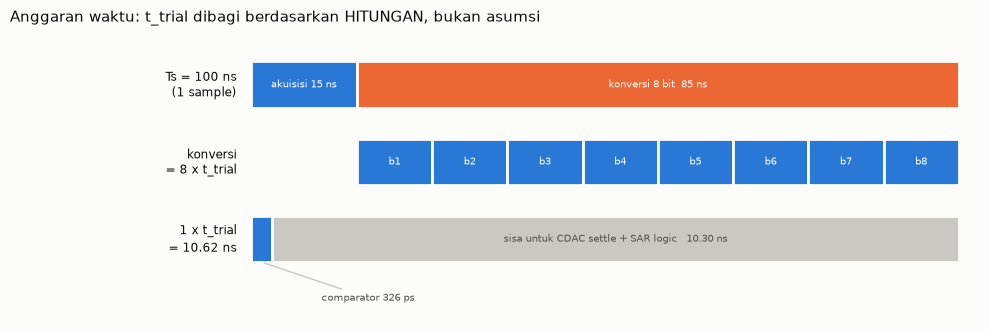

In [12]:
POS, NEG = '#2a78d6', '#eb6834'
INK, INK2, MUTED, GRID, SURF = '#0b0b0b', '#52514e', '#c9c8c2', '#e6e5e0', '#fcfcfb'

def dress(ax):
    ax.set_facecolor(SURF)
    for s in ('top', 'right'): ax.spines[s].set_visible(False)
    for s in ('left', 'bottom'):
        ax.spines[s].set_color(GRID); ax.spines[s].set_linewidth(1)
    ax.tick_params(colors=INK2, labelsize=8, length=3, width=1)

t_rest = t_trial - t_need
figA, ax = plt.subplots(figsize=(10, 3.4)); figA.patch.set_facecolor(SURF); dress(ax)
rows_ = [
    (2, f'Ts = {Ts*1e9:.0f} ns\n(1 sample)', 1/Ts,
     [(0, T_SAMPLE, POS, f'akuisisi {T_SAMPLE*1e9:.0f} ns'),
      (T_SAMPLE, t_conv, NEG, f'konversi {N} bit  {t_conv*1e9:.0f} ns')]),
    (1, f'konversi\n= {N} x t_trial', 1/Ts,
     [(T_SAMPLE+i*t_trial, t_trial, POS, f'b{i+1}') for i in range(N)]),
    (0, f'1 x t_trial\n= {t_trial*1e9:.2f} ns', 1/t_trial,
     [(0, t_need, POS, ''), (t_need, t_rest, MUTED,
      f'sisa untuk CDAC settle + SAR logic   {t_rest*1e9:.2f} ns')]),
]
for y, label, s, segs in rows_:
    for x0, w, c, txt in segs:
        ax.add_patch(Rectangle((x0*s, y-0.3), w*s, 0.6, facecolor=c,
                               edgecolor=SURF, linewidth=2, zorder=2))
        if txt and w*s > 0.10:
            ax.text(x0*s+w*s/2, y, txt, ha='center', va='center', fontsize=7.5,
                    color='white' if c != MUTED else INK2, zorder=3)
    ax.text(-0.02, y, label, ha='right', va='center', fontsize=8.5, color=INK, linespacing=1.4)
ax.annotate(f'comparator {t_need*1e12:.0f} ps', xy=(t_need/t_trial/2, -0.30),
            xytext=(0.10, -0.80), fontsize=7.5, color=INK2,
            arrowprops=dict(arrowstyle='-', color=MUTED, lw=1))
ax.set_xlim(-0.34, 1.03); ax.set_ylim(-1.05, 2.6)
ax.set_yticks([]); ax.set_xticks([])
ax.spines['left'].set_visible(False); ax.spines['bottom'].set_visible(False)
ax.set_title('Anggaran waktu: t_trial dibagi berdasarkan HITUNGAN, bukan asumsi',
             fontsize=11, color=INK, pad=12, loc='left')
figA.tight_layout(); plt.show()

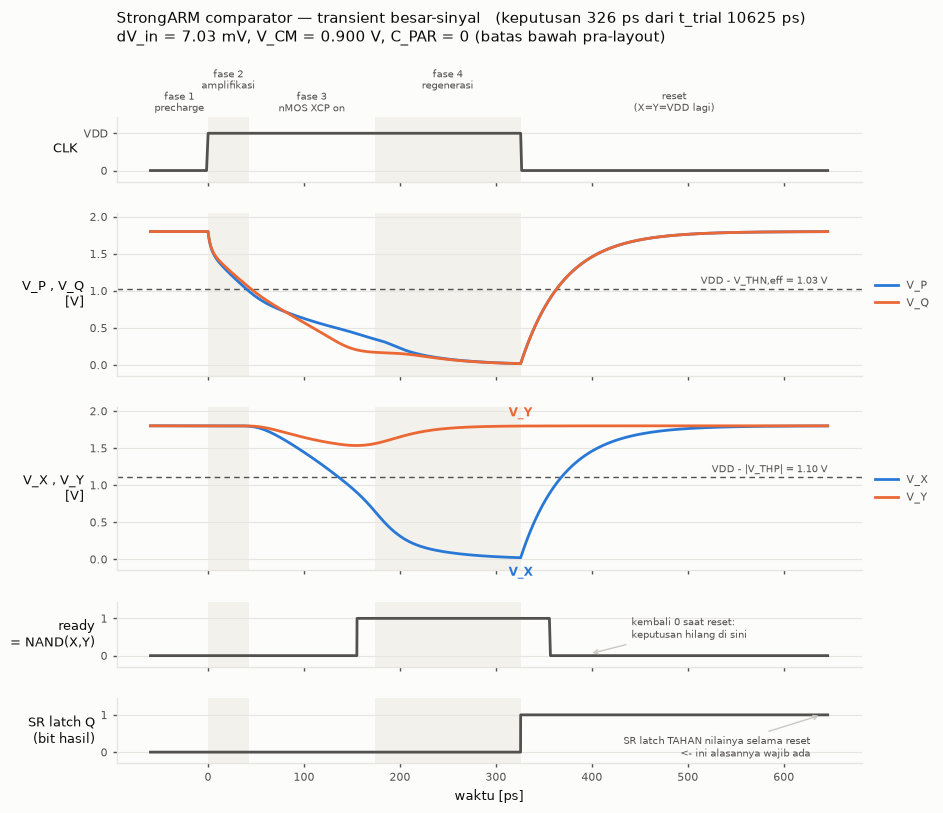

In [13]:
tau_rst = 45e-12
t_r = np.linspace(0, 320e-12, 300); e = np.exp(-t_r/tau_rst); t_pre = 60e-12
tp = np.concatenate([np.linspace(-t_pre, 0, 40), tt, tt[-1]+t_r])
def seq(v, last): return np.concatenate([np.full(40, VDD), v, VDD-(VDD-last)*e])
VP, VQ, VX, VY = seq(vp, vp[-1]), seq(vq, vq[-1]), seq(vx, vx[-1]), seq(vy, vy[-1])
clk   = np.where((tp >= 0) & (tp <= tt[-1]), 1.0, 0.0)
ready = ((VX < 0.5*VDD) | (VY < 0.5*VDD)).astype(float)
srq   = np.where(tp < tt[-1], 0.0, 1.0)
bands = [(-t_pre, 0, 'fase 1\nprecharge'), (0, tt[i_a], 'fase 2\namplifikasi'),
         (tt[i_a], tt[i_b], 'fase 3\nnMOS XCP on'), (tt[i_b], tt[-1], 'fase 4\nregenerasi'),
         (tt[-1], tp[-1], 'reset\n(X=Y=VDD lagi)')]

figB, axes = plt.subplots(5, 1, figsize=(10, 8.4), sharex=True,
                          gridspec_kw={'height_ratios': [.5, 1.25, 1.25, .5, .5], 'hspace': .3})
figB.patch.set_facecolor(SURF); ps = tp*1e12
for kk, ax in enumerate(axes):
    dress(ax)
    for i, (a, b, lab) in enumerate(bands):
        if i % 2 == 1: ax.axvspan(a*1e12, b*1e12, color='#f2f1ec', zorder=0, lw=0)
        if kk == 0:
            ax.text((a+b)/2*1e12, 1.52 + 0.60*(i % 2), lab, ha='center', va='bottom',
                    fontsize=7, color=INK2, linespacing=1.25)
    ax.grid(axis='y', color=GRID, lw=.8, zorder=0); ax.set_axisbelow(True)
def ylab(ax, s): ax.set_ylabel(s, fontsize=9, color=INK, rotation=0, ha='right', va='center')

axes[0].plot(ps, clk, color=INK2, lw=2, zorder=3); ylab(axes[0], 'CLK')
axes[0].set_ylim(-.3, 1.45); axes[0].set_yticks([0, 1]); axes[0].set_yticklabels(['0', 'VDD'])
for ax, a, b, na, nb, thr, txt in (
        (axes[1], VP, VQ, 'V_P', 'V_Q', VDD-VTHN_eff, f'VDD - V_THN,eff = {VDD-VTHN_eff:.2f} V'),
        (axes[2], VX, VY, 'V_X', 'V_Y', VDD-VTHP,     f'VDD - |V_THP| = {VDD-VTHP:.2f} V')):
    ax.plot(ps, a, color=POS, lw=2, zorder=3, label=na)
    ax.plot(ps, b, color=NEG, lw=2, zorder=3, label=nb)
    ax.axhline(thr, color=INK2, lw=1, ls=(0, (4, 3)), zorder=2)
    ax.text(ps[-1], thr+.07, txt, ha='right', fontsize=7.5, color=INK2)
    ylab(ax, f'{na} , {nb}\n[V]'); ax.set_ylim(-.15, 2.05)
    i = int(np.argmax(np.abs(a-b)))
    if abs(a[i]-b[i]) > 0.35:
        lower = (na, a[i], POS) if a[i] < b[i] else (nb, b[i], NEG)
        upper = (nb, b[i], NEG) if a[i] < b[i] else (na, a[i], POS)
        for (nm_, yv, cc), dy in ((lower, -13), (upper, 7)):
            ax.annotate(nm_, xy=(ps[i], yv), xytext=(0, dy), textcoords='offset points',
                        fontsize=8.5, color=cc, ha='center', fontweight='bold')
    ax.legend(loc='center left', bbox_to_anchor=(1.005, .5), fontsize=8,
              frameon=False, labelcolor=INK2)
axes[3].plot(ps, ready, color=INK2, lw=2, zorder=3)
ylab(axes[3], 'ready\n= NAND(X,Y)'); axes[3].set_ylim(-.3, 1.45); axes[3].set_yticks([0, 1])
axes[3].annotate('kembali 0 saat reset:\nkeputusan hilang di sini',
                 xy=((tt[-1]+1.6*tau_rst)*1e12, .05), xytext=(30, 18),
                 textcoords='offset points', fontsize=7.5, color=INK2, ha='left', va='center',
                 arrowprops=dict(arrowstyle='->', color=MUTED, lw=1))
axes[4].plot(ps, srq, color=INK2, lw=2, zorder=3)
ylab(axes[4], 'SR latch Q\n(bit hasil)'); axes[4].set_ylim(-.3, 1.45); axes[4].set_yticks([0, 1])
axes[4].annotate('SR latch TAHAN nilainya selama reset\n<- ini alasannya wajib ada',
                 xy=(ps[-1]*.99, 1), xytext=(-8, -30), textcoords='offset points',
                 fontsize=7.5, color=INK2, ha='right',
                 arrowprops=dict(arrowstyle='->', color=MUTED, lw=1))
axes[4].set_xlabel('waktu [ps]', fontsize=9, color=INK)
axes[0].set_title(f'StrongARM comparator — transient besar-sinyal   '
                  f'(keputusan {tt[-1]*1e12:.0f} ps dari t_trial {t_trial*1e12:.0f} ps)\n'
                  f'dV_in = {dV_in*1e3:.2f} mV, V_CM = {V_CM_MAX:.3f} V, '
                  f'C_PAR = 0 (batas bawah pra-layout)',
                  fontsize=11, color=INK, pad=54, loc='left')
figB.subplots_adjust(right=.87); plt.show()

## Langkah 12 — Tabel device dan back-annotation xschem

In [14]:
def fold(W, target=1.2):
    nf = max(1, int(np.ceil(W/target)))
    return nf, round(W/nf, 3)

devices = [
    ('M0a/M0b', 'input pair',    DEV_IN_NAME, W1,     L_IN),
    ('M1a/M1b', 'nMOS XCP',      'nfet_01v8', W3,     L34),
    ('M2a/M2b', 'pMOS XCP',      'pfet_01v8', W5,     L56),
    ('M3',      'tail switch',   'nfet_01v8', W_TAIL, L_TAIL),
    ('M4a/M4b', 'precharge X,Y', 'pfet_01v8', W_SW,   L_SW),
    ('M5a/M5b', 'precharge P,Q', 'pfet_01v8', W_SW,   L_SW),
]
print(f'{"nama sch":10s} {"peran":16s} {"model":16s} {"W[um]":>7s} {"L[um]":>6s} {"nf":>3s} {"W/f":>6s}')
print('-'*70)
for nm, role, model, W, L in devices:
    nf, wf = fold(round(W, 3))
    print(f'{nm:10s} {role:16s} {model:16s} {round(W,3):7.2f} {L:6.2f} {nf:3d} {wf:6.3f}')
print(f'\nbuffer inverter (di luar comparator): Wn={BUF_WN} Wp={BUF_WP} L={L_MIN} um')
print(f'SR latch: 2 x NAND2 di belakang buffer')
print('\n--- string parameter xschem ---')
for nm, role, model, W, L in devices:
    nf, wf = fold(round(W, 3))
    print(f'\n{nm}  ({role})\n  W={round(W,3)}\n  L={L}\n  nf={nf}\n  model={model}')

nama sch   peran            model              W[um]  L[um]  nf    W/f
----------------------------------------------------------------------
M0a/M0b    input pair       nfet_01v8_lvt       5.00   0.20   5  1.000
M1a/M1b    nMOS XCP         nfet_01v8           0.42   0.15   1  0.420
M2a/M2b    pMOS XCP         pfet_01v8           0.42   0.15   1  0.420
M3         tail switch      nfet_01v8           0.42   0.15   1  0.420
M4a/M4b    precharge X,Y    pfet_01v8           0.42   0.15   1  0.420
M5a/M5b    precharge P,Q    pfet_01v8           0.42   0.15   1  0.420

buffer inverter (di luar comparator): Wn=0.42 Wp=1.31 L=0.15 um
SR latch: 2 x NAND2 di belakang buffer

--- string parameter xschem ---

M0a/M0b  (input pair)
  W=5.0
  L=0.2
  nf=5
  model=nfet_01v8_lvt

M1a/M1b  (nMOS XCP)
  W=0.42
  L=0.15
  nf=1
  model=nfet_01v8

M2a/M2b  (pMOS XCP)
  W=0.42
  L=0.15
  nf=1
  model=pfet_01v8

M3  (tail switch)
  W=0.42
  L=0.15
  nf=1
  model=nfet_01v8

M4a/M4b  (precharge X,Y)
  W=0.42
  

## Daftar yang masih terbuka

Semua ini sekarang **terlihat di kode** sebagai `None` atau `0`, bukan tersembunyi sebagai
angka karangan:

| Slot | Di mana | Cara mengisinya |
|---|---|---|
| `AVT_N`, `AVT_P`, `SIGMA_OFF_MC` | Langkah 3 | Monte Carlo — resep lengkap tercetak di Langkah 10 |
| `C_PAR_PQ`, `C_PAR_XY` | Langkah 3 | PEX setelah layout. Sensitivitasnya sudah di-sweep di Langkah 9 |
| clamp `VSB` di 0.4 V | Langkah 4 & 8 | Batas sumbu tabel `.mat`. Membuat `V_THN,eff` dan kecepatan transient **optimis**. Cek di SPICE |
| `T_SAMPLE` | Langkah 3 | Ditentukan bandwidth bootstrapped switch — blok itu belum didesain |
| `RESERVE` | Langkah 3 | Porsi daya disisihkan untuk noise VREF + jitter. Kunci setelah keduanya diukur |
| ripple VREF | belum | Kopling VREF->differensial = 0.50 rata-rata (0.99 worst). Suku ini dulu TIDAK ADA di anggaran |
| `sigma_jitter` | belum | Aperture jitter clock TT. Suku ini dulu TIDAK ADA di anggaran |
| `dVos/dVcm` | belum | Sweep DC V_CM 0.79..0.90 V, cari trip point tiap titik. Menentukan `N_SPLIT` |
| SR latch | belum digambar | Razavi Fig. 4. Buffer inverter-nya sudah masuk `C_X,Y` |
| transient noise | belum | Metode Monte-Carlo paper hal. 15. Eq (15) hanya mencakup fase amplifikasi |
| kickback | belum | Paper hal. 16 |
| corner | belum | Titik tetap `V_THN` dan headroom tail paling rawan di SS/dingin dan FF/panas |